# Campione d'inverno e scudetto

Due domande, sui dati veri della Serie A.

1. Qual è la probabilità che il campione d'inverno vinca lo scudetto? Il calcolo è fatto all'inverno, cioè a fine girone di andata.
2. E l'Inter, da campione d'inverno, che probabilità ha?

I dati arrivano già puliti da `data/silver/` (la pipeline è negli script, vedi README). Qui c'è solo l'analisi.

### Librerie

In [1]:
import pandas as pd
import requests
from datetime import datetime
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score,train_test_split,StratifiedKFold,GridSearchCV 
from sklearn.metrics import accuracy_score,recall_score,classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

C:\Users\MartinoCrippa\AppData\Roaming\Python\Python314\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np

class SerieADataProcessor:
    def __init__(self, campionati_dict):
        self.raw_data = campionati_dict
        self.final_dataset = pd.DataFrame()
        self.features = []
        self.model = None # Verrà impostato esternamente[cite: 1]

    def _parse_date_safe(self, date_str):
        for fmt in ("%d/%m/%Y", "%d/%m/%y", "%Y-%m-%d", "%d-%m-%Y"):
            try: return pd.to_datetime(str(date_str), format=fmt)
            except: continue
        return pd.NaT

    def _calculate_winter_stats(self, df_season, season_id):
        # Selezione colonne core dal notebook originale[cite: 1]
        m = df_season[["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]].copy()
        m["Date"] = m["Date"].apply(self._parse_date_safe)
        m = m.sort_values("Date").dropna(subset=["FTHG", "FTAG"]).reset_index(drop=True)

        teams = pd.unique(pd.concat([m["HomeTeam"], m["AwayTeam"]]))
        games_in_half_season = len(teams) - 1
        
        stats = pd.DataFrame(index=teams, data={
            "GP": 0, "W": 0, "D": 0, "L": 0, "GF": 0, "GA": 0, "Pts": 0
        })

        winter_record = None
        for _, row in m.iterrows():
            h, a, hg, ag = row["HomeTeam"], row["AwayTeam"], int(row["FTHG"]), int(row["FTAG"])
            for team, g_for, g_against in [(h, hg, ag), (a, ag, hg)]:
                stats.loc[team, "GP"] += 1
                stats.loc[team, "GF"] += g_for
                stats.loc[team, "GA"] += g_against
                if g_for > g_against: 
                    stats.loc[team, "Pts"] += 3; stats.loc[team, "W"] += 1
                elif g_for < g_against: 
                    stats.loc[team, "L"] += 1
                else: 
                    stats.loc[team, "Pts"] += 1; stats.loc[team, "D"] += 1

            if winter_record is None and stats["GP"].min() >= games_in_half_season:
                table = stats.copy()
                table["GD"] = table["GF"] - table["GA"]
                table = table.sort_values(by=["Pts", "GD", "GF"], ascending=False)
                champ = table.index[0]
                winter_record = table.iloc[0].to_dict()
                winter_record.update({
                    "Team": champ, "Season": season_id,
                    "GapOnSecond": winter_record["Pts"] - table.iloc[1]["Pts"],
                    "WinRate": winter_record["W"] / winter_record["GP"],
                    "AvgGoalScored": winter_record["GF"] / winter_record["GP"],
                    "AvgGoalConceded": winter_record["GA"] / winter_record["GP"]
                })

        final_winner = stats.assign(GD=stats.GF-stats.GA).sort_values(["Pts","GD","GF"], ascending=False).index[0]
        if winter_record:
            winter_record["WonScudetto"] = 1 if winter_record["Team"] == final_winner else 0
            return winter_record
        return None

    def build_training_set(self):
        records = []
        for sid, df in self.raw_data.items():
            try:
                record = self._calculate_winter_stats(df, sid)
                if record: records.append(record)
            except Exception as e:
                print(f"Errore stagione {sid}: {e}")
        
        df = pd.DataFrame(records)
        cols_id = ["Team", "Season"]
        col_target = ["WonScudetto"]
        self.features = [c for c in df.columns if c not in cols_id + col_target]
        self.final_dataset = df[cols_id + self.features + col_target]
        return self.final_dataset

    def set_trained_model(self, model):
        """Metodo SWE: Dependency Injection del modello addestrato esternamente."""
        self.model = model

    def predici_scudetto(self, nome_squadra, dati_attuali):
        """Esegue la predizione usando il modello iniettato."""
        if self.model is None:
            raise ValueError("Il modello non è stato impostato. Usa processor.set_trained_model(model).")
            
        input_df = pd.DataFrame([dati_attuali])
        input_df = input_df[self.features] # Garantisce l'allineamento delle feature[cite: 1]
        
        prob = self.model.predict_proba(input_df)[0]
        
        print(f"\n--- Analisi Modello: {nome_squadra} ---")
        print(f"Probabilità vittoria finale: {prob[1]:.2%}")
        return prob[1]

## I dati

Una stagione per file in `data/silver/`, con le sole colonne che servono: data, squadre, gol. Li carico in un dizionario `campionati`, chiave = stagione.

In [3]:
# Carico le stagioni pulite da data/silver/: chiave = stagione, valore = DataFrame.
from pathlib import Path

SILVER = Path("../data/silver")
campionati = {
    f.stem.replace("I1_", ""): pd.read_csv(f)
    for f in sorted(SILVER.glob("I1_*.csv"))
}
print("Stagioni caricate:", len(campionati))

Stagioni caricate: 32


## Domanda 1 - la probabilità storica

Quante volte, dal 1993/94 a oggi, il campione d'inverno ha poi vinto lo scudetto?

Per ogni stagione ricostruisco la classifica fino alla fine del girone di andata (l'inverno), prendo il primo, e guardo se è lo stesso che vince a fine stagione.

In [4]:
def parseDateSafe(x):

    for fmt in ("%d/%m/%Y", "%d/%m/%y", "%Y-%m-%d", "%d-%m-%Y"):
        try:
            return datetime.strptime(str(x), fmt)
        except:
            continue
    return pd.NaT

def matchesBuilder(df: pd.DataFrame) -> pd.DataFrame:
    """
    In: dataframe
    Out: dataframe

    Pulisco il dataset che avevo in entrata andando a fare una feature selection di cio che serve a me
    """
   
    colonneDaMappare = {
        "HomeTeam": "HomeTeam",
        "AwayTeam": "AwayTeam",
        "FTHG": "FTHG",
        "FTAG": "FTAG",
        "Date": "Date",
    }

    out = df[list(colonneDaMappare.keys())].copy()

   # ho dovuto aggiungere la funzione parseDateSafe per evitare problemi tra formati 
    out["Date"] = out["Date"].apply(parseDateSafe)

    out = out.sort_values(["Date"], na_position="last").reset_index(drop=True)
    
    out["FTHG"] = pd.to_numeric(out["FTHG"], errors="coerce")
    out["FTAG"] = pd.to_numeric(out["FTAG"], errors="coerce")

    
    out = out.dropna(subset=["HomeTeam", "AwayTeam", "FTHG", "FTAG"]).reset_index(drop=True)

    return out

def classificaBuilder(df_season: pd.DataFrame):
    """
    In: dataframe
    Out: variabili winter,final che poi andro appaire in un secondo momento per creare il df finale 
    
    """
    m = matchesBuilder(df_season)

    teams = pd.unique(pd.concat([m["HomeTeam"], m["AwayTeam"]], ignore_index=True))
    n_teams = len(teams)
    half_games = n_teams - 1

    table = pd.DataFrame(index=teams, data={"GP": 0, "GF": 0, "GA": 0, "Pts": 0})
    winter = None

    for _, r in m.iterrows():
        h, a = r["HomeTeam"], r["AwayTeam"]
        hg, ag = int(r["FTHG"]), int(r["FTAG"])

        table.loc[[h, a], "GP"] += 1
        table.loc[h, "GF"] += hg
        table.loc[h, "GA"] += ag
        table.loc[a, "GF"] += ag
        table.loc[a, "GA"] += hg

        if hg > ag:
            table.loc[h, "Pts"] += 3
        elif hg < ag:
            table.loc[a, "Pts"] += 3
        else:
            table.loc[[h, a], "Pts"] += 1

        if winter is None and table["GP"].min() >= half_games:
            tmp = table.copy()
            tmp["GD"] = tmp["GF"] - tmp["GA"]
            winter = tmp.sort_values(["Pts", "GD", "GF"], ascending=False).index[0]

    tmp = table.copy()
    tmp["GD"] = tmp["GF"] - tmp["GA"]
    final = tmp.sort_values(["Pts", "GD", "GF"], ascending=False).index[0]

    return winter, final

In [5]:
results = []

for season, df in campionati.items():
    try:
        winter, final = classificaBuilder(df)
        results.append((season, winter, final, winter == final))
    except Exception as e:
        results.append((season, None, None, None))
        print("Errore su", season, ":", repr(e))

res = pd.DataFrame(results, columns=["season", "winter", "final", "same"]).sort_values("season")
print(res)

print("P(scudetto | campione d'inverno) =", res["same"].mean())

   season      winter     final   same
0    0001        Roma      Roma   True
1    0102        Roma  Juventus  False
2    0203       Milan  Juventus  False
3    0304        Roma     Milan  False
4    0405    Juventus  Juventus   True
5    0506    Juventus  Juventus   True
6    0607       Inter     Inter   True
7    0708       Inter     Inter   True
8    0809       Inter     Inter   True
9    0910       Inter     Inter   True
10   1011       Milan     Milan   True
11   1112    Juventus  Juventus   True
12   1213    Juventus  Juventus   True
13   1314    Juventus  Juventus   True
14   1415    Juventus  Juventus   True
15   1516      Napoli  Juventus  False
16   1617    Juventus  Juventus   True
17   1718      Napoli  Juventus  False
18   1819    Juventus  Juventus   True
19   1920    Juventus  Juventus   True
20   2021       Milan     Inter  False
21   2122       Inter     Milan  False
22   2223      Napoli    Napoli   True
23   2324       Inter     Inter   True
24   2425      Napoli    

## Domanda 2 - e l'Inter?

La probabilità storica è una media. Qui proviamo a stimarla a partire da quanto era forte il campione d'inverno: differenza reti e distacco sul secondo a metà stagione. Poi applichiamo il modello al caso dell'Inter.

In [6]:
processor = SerieADataProcessor(campionati)
setDati = processor.build_training_set()
setDati = setDati[['Team','Season','GapOnSecond','GD','WonScudetto']]
print(f"Dataset creato con {len(setDati)} record storici.")
print(setDati)

Dataset creato con 32 record storici.
          Team Season  GapOnSecond  GD  WonScudetto
0         Roma   0001            6  20            1
1         Roma   0102            4  17            0
2        Milan   0203            3  23            0
3         Roma   0304            0  29            0
4     Juventus   0405            2  23            1
5     Juventus   0506           10  31            1
6        Inter   0607            9  25            1
7        Inter   0708            5  30            1
8        Inter   0809            3  18            1
9        Inter   0910            6  24            1
10       Milan   1011            4  17            1
11    Juventus   1112            1  20            1
12    Juventus   1213            5  27            1
13    Juventus   1314            8  34            1
14    Juventus   1415            5  33            1
15      Napoli   1516            4  25            0
16    Juventus   1617            1  24            1
17      Napoli   1718     

# ML: Classificazione

In [7]:
processor.features = ['GD', 'GapOnSecond']

X = setDati[processor.features]
y = setDati["WonScudetto"]
features = [c for c in setDati.columns if c not in ["Team", "Season", "WonScudetto"]]

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.80,random_state=42)

In [9]:
model = LogisticRegression()

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]
preds = model.predict(X_test)

from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.7142857142857143
ROC AUC: 0.5


In [10]:
processor.set_trained_model(model)
inter2526 = {
    
    'GD': 26, 'GapOnSecond': 3
}
processor.predici_scudetto("Inter",inter2526)


--- Analisi Modello: Inter ---
Probabilità vittoria finale: 74.17%


np.float64(0.741720196120818)

In [11]:
processor.features = ['GD', 'GapOnSecond']
X= setDati.drop(columns=["Team","Season","WonScudetto"])
y= setDati["WonScudetto"]

In [12]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

In [13]:
loo = LeaveOneOut()

model = LogisticRegression()

y_true = []
y_pred = []
y_prob = []

In [14]:
for train_index, test_index in loo.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]
    prob = model.predict_proba(X_test)[0][1]

    y_pred.append(pred)
    y_prob.append(prob)
    y_true.append(y_test.values[0])

In [15]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("ROC AUC:", roc_auc_score(y_true, y_prob))

Accuracy: 0.625
ROC AUC: 0.5748792270531401


In [16]:
print("Probabilità media scudetto campione d'inverno:", np.mean(y_prob))

Probabilità media scudetto campione d'inverno: 0.7189093659285921


In [17]:
model.fit(X, y)

inter = pd.DataFrame([{
    'GapOnSecond': 3,
    'GD': 26
}])

p=float(((model.predict_proba(inter)[0][1])).round(3)*100)
print(f"Probabilità che l'inter vinca lo scudetto: {p}%")

Probabilità che l'inter vinca lo scudetto: 69.3%


## Bontà del modello

Con così pochi dati la valutazione onesta è quella out-of-fold: uso le predizioni della cross-validation Leave-One-Out (ogni stagione predetta da un modello che non l'ha vista). ROC e matrice di confusione su quelle.

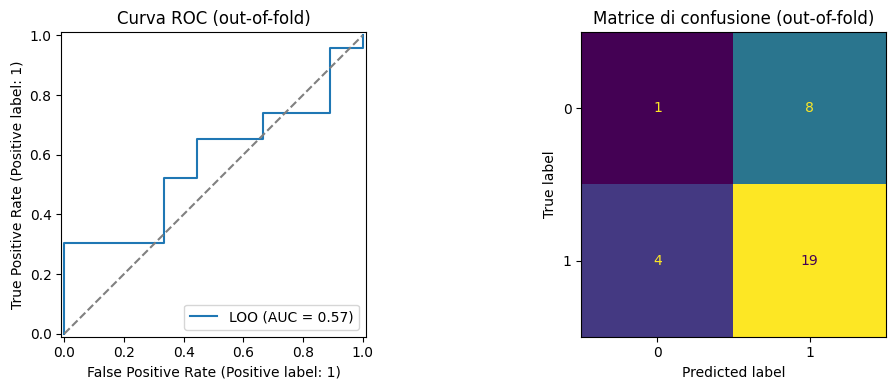

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax[0], name="LOO")
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set_title("Curva ROC (out-of-fold)")

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax[1], colorbar=False)
ax[1].set_title("Matrice di confusione (out-of-fold)")

plt.tight_layout()
plt.show()

## In sintesi

- Storicamente il campione d'inverno vince lo scudetto circa il 72% delle volte (23 su 32).
- Il modello, sulle stesse stagioni, dà stime in linea (Inter intorno al 70%).

32 stagioni sono poche: è una tendenza, non una legge. Da qui nascono altre domande - altri campionati, il peso del distacco, com'è cambiata nel tempo.